# General notebook

In [1]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
Starting backtracking
Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


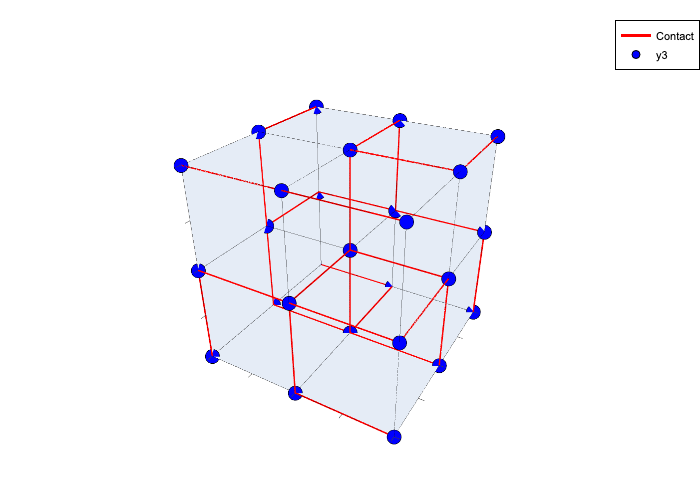

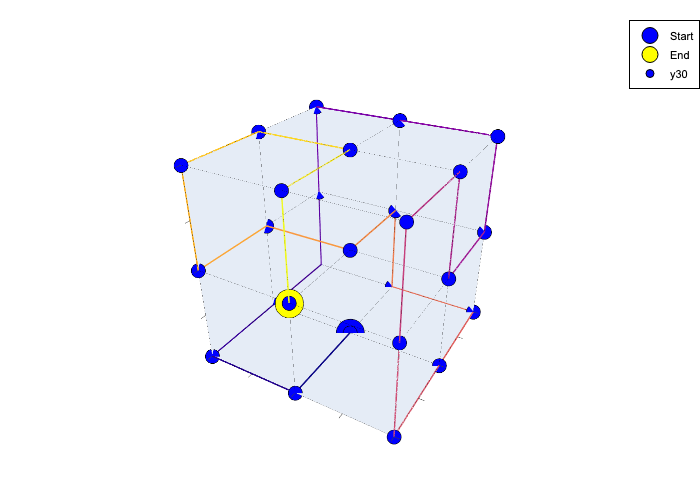

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut tester MJ*5 il faut restart le kernel et modifier la ligne const dans le ficher file_metropolis.jl. 

In [ ]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:19


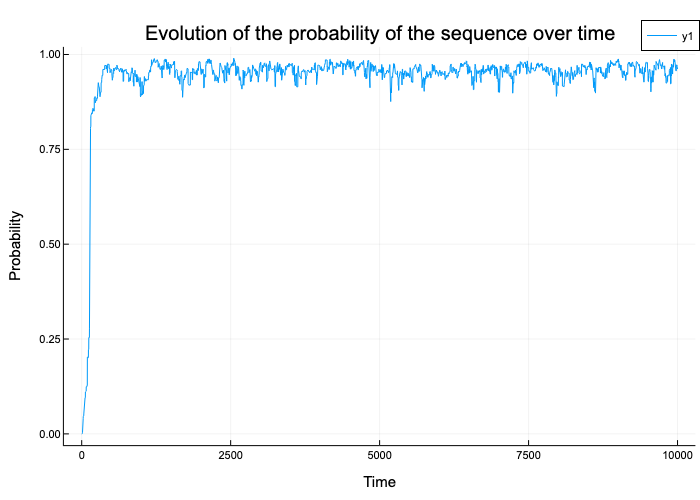

In [2]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:08


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:06


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:08


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:07


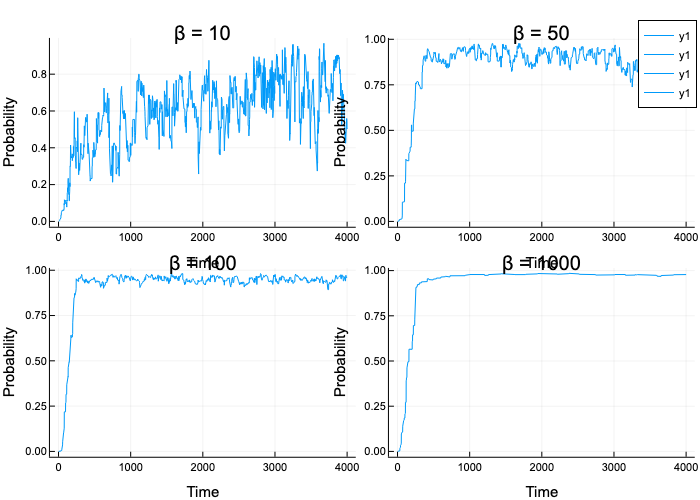

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([14, 15, 15, 19, 4, 11, 16, 3, 2, 19  …  2, 14, 7, 3, 20, 1, 15, 7…
  10.0   => ([7, 20, 9, 19, 14, 8, 16, 20, 18, 1  …  16, 5, 19, 12, 1, 13, 3, 1…
  1000.0 => ([6, 12, 15, 5, 15, 16, 6, 17, 1, 18  …  1, 16, 4, 4, 1, 18, 15, 7,…
  100.0  => ([14, 12, 8, 19, 18, 12, 15, 16, 3, 14  …  7, 14, 19, 15, 5, 15, 15…

In [19]:
benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:01:36


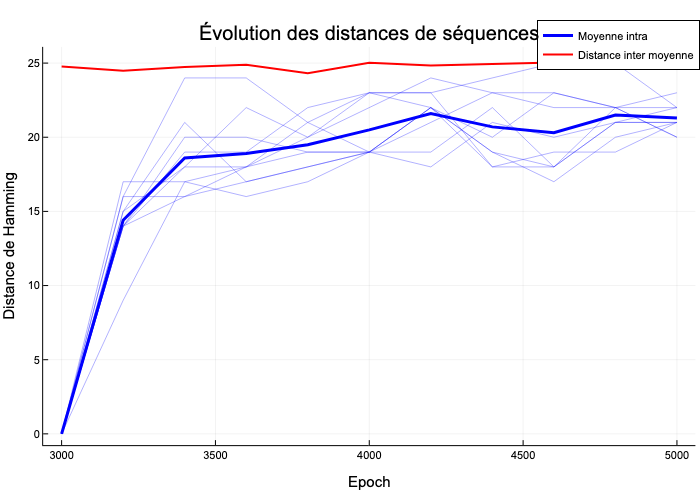

In [23]:
seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=5000, beta=100.0, threshold=3000, step=200, runs=10)
plot_distances_inter_intra(seq_over_time)

### All proba

In [24]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:18


structure 1234 : 0.946173917380715
structure 1797 : 0.014188423663614821
structure 2332 : 0.008605713964974664
structure 1558 : 0.007407006652486193
structure 9583 : 0.007045762675317302
structure 529 : 0.003011464174397694
structure 493 : 0.0025919912356223507
structure 9644 : 0.0024655783313719307
structure 532 : 0.0019201943351963731
structure 1777 : 0.001164656736903107
structure 1271 : 0.0009070355787095339
structure 3118 : 0.000706400018972609
structure 2286 : 0.0004977916799470712
structure 3084 : 0.0004284532695284719
structure 7760 : 0.00016570045595987
structure 8555 : 0.00014993197273810988
structure 1785 : 0.0001499319727381086
structure 1166 : 0.00012275391695033876
structure 1113 : 9.093833833686218e-5
structure 1233 : 9.093833833686212e-5
